# Kunitz Domain HMM Pipeline Notebook

This notebook outlines a pipeline for building and validating a Profile Hidden Markov Model (HMM) for detecting Kunitz domains (Pfam: PF00014). The process involves:

1.  **Data Gathering:** Obtaining an initial list of PDB structures containing Kunitz domains.
2.  **Filtering:** Reducing redundancy using CD-HIT.
3.  **Data Splitting:** Separating data into training and test sets.
4.  **Data Processing:** Extracting the specific Kunitz domain structures from the full PDB files based on Pfam annotations.
5.  **Structural Alignment:** Aligning the training set Kunitz domain structures using MUSTANG.
6.  **HMM Building:** Constructing an HMM from the structural alignment using HMMER.
7.  **HMM Validation:** Testing the HMM's performance on a combined positive/negative test set.
8.  **SwissProt Annotation:** Using the HMM to search the SwissProt database for potential Kunitz domains.
9.  **Comparison:** Comparing the HMM predictions against existing SwissProt annotations.

In [1]:
import pandas as pd
import numpy as np
import requests
import time
import os
import re 
import subprocess
import shutil
import random
from Bio import PDB
from Bio import SearchIO
from Bio import SeqIO 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve, roc_curve, auc
import gc
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Define Base Directories
BASE_DATA_DIR        = "data"
INPUT_DIR            = f"{BASE_DATA_DIR}/input_data"
FASTA_DIR            = f"{BASE_DATA_DIR}/fasta_full" # Directory for full FASTAs
PDB_DIR              = f"{BASE_DATA_DIR}/pdbs" # Directory for downloaded full PDBs
KUNITZ_PDB_TRAIN_DIR = f"{BASE_DATA_DIR}/kunitz_pdbs_train"
KUNITZ_PDB_TEST_DIR  = f"{BASE_DATA_DIR}/kunitz_pdbs_test"
HMM_DIR              = f"{BASE_DATA_DIR}/hmms"
TEST_DATA_DIR        = f"{BASE_DATA_DIR}/test_data" # For combined test sequences
SWISS_DIR            = f"{BASE_DATA_DIR}/swiss_data"

# Create directories if they don't exist
os.makedirs(INPUT_DIR, exist_ok=True)
os.makedirs(FASTA_DIR, exist_ok=True)
os.makedirs(PDB_DIR, exist_ok=True)
os.makedirs(KUNITZ_PDB_TRAIN_DIR, exist_ok=True)
os.makedirs(KUNITZ_PDB_TEST_DIR, exist_ok=True)
os.makedirs(HMM_DIR, exist_ok=True)
os.makedirs(TEST_DATA_DIR, exist_ok=True)
os.makedirs(SWISS_DIR, exist_ok=True)

print("Directories created/verified.")

Directories created/verified.


## Data Gathering (Initial PDB/Chain List)

The process begins by obtaining a list of PDB structures potentially containing Kunitz domains. This is done by parsing a pre-downloaded CSV report from the RCSB PDB website. The search criteria used to generate this report targeted structures associated with Pfam ID **PF00014**, filtered for resolution (<= 3.0 Å).

The code loads this report, filters for the relevant PF00014 annotation, and extracts unique combinations of PDB ID, Author Chain ID, and the corresponding protein sequence.

In [3]:
# Inside the report you need => "PDB ID", "Sequence", "Asym ID", "Auth Asym ID", "Annotation Identifier"
report_file = f"{INPUT_DIR}/rcsb_report3.csv" 

df_report = pd.read_csv(report_file)

# Restructure the dataframe if header is on the second row
if df_report.columns[0] != "PDB ID":
    df_report.columns = df_report.iloc[0]
    df_report = df_report[1:]
    df_report.reset_index(drop=True, inplace=True)

print("RCSB Report Loaded:")
df_ids = df_report[df_report["Annotation Identifier"] == "PF00014"].copy() # Use .copy() to avoid SettingWithCopyWarning
df_ids["PDB ID"].fillna(method="ffill", inplace=True) # # Fill missing PDB IDs with the last valid PDB ID (forward fill)
df_ids.reset_index(drop=True, inplace=True)

df_ids

RCSB Report Loaded:


,Entry ID,PDB ID,Sequence,Asym ID,Auth Asym ID,Annotation Identifier,Annotation Type,Entity ID,NaN
0,1AAL,1AAL,RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFK...,A,A,PF00014,Pfam,1,NaN
1,1AAP,1AAP,VREVCSEQAETGPCRAMISRWYFDVTEGKCAPFFYGGCGGNRNNFD...,A,A,PF00014,Pfam,1,NaN
2,1B0C,1B0C,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,B,B,PF00014,Pfam,1,NaN
3,1BHC,1BHC,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,A,A,PF00014,Pfam,1,NaN
4,1BIK,1BIK,AVLPQEEEGSGGGQLVTEVTKKEDSCQLGYSAGPCMGMTSRYFYNG...,A,A,PF00014,Pfam,1,NaN
...,...,...,...,...,...,...,...,...,...
162,NaN,7PTI,RPDFCLEPPYTGPCXARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,D,D,PF00014,Pfam,4,NaN
163,NaN,7PTI,RPDFCLEPPYTGPCXARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,D,D,PF00014,Pfam,4,NaN
164,NaN,7PTI,RPDFCLEPPYTGPCXARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,D,D,PF00014,Pfam,4,NaN
165,8PTI,8PTI,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVGGGCRAKRNNFK...,A,A,PF00014,Pfam,1,NaN


In [4]:
initial_candidates = df_ids[["PDB ID", "Auth Asym ID", "Sequence"]].drop_duplicates().to_dict(orient="records")

print(f"Found {len(initial_candidates)} initial PDB ID/Chain candidates from {len(df_ids['PDB ID'].unique())} unique PDB IDs.")
print(f"Example candidate: {initial_candidates[0]}")


Found 152 initial PDB ID/Chain candidates from 60 unique PDB IDs.
Example candidate: {'PDB ID': '1AAL', 'Auth Asym ID': 'A', 'Sequence': 'RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFKSAEDAMRTCGGA'}


### Creating Initial FASTA File


The extracted sequences (PDB ID, Chain ID, Sequence) are formatted into a standard FASTA file (`initial_candidates.fasta`). The FASTA header for each sequence is set to `>PDBID_ChainID` for easy identification later.

In [5]:
# Define the output FASTA file path
output_fasta_path = f"{FASTA_DIR}/initial_candidates.fasta"

# Write the sequences to the FASTA file
with open(output_fasta_path, "w") as fasta_file:
    for candidate in initial_candidates:
        pdb_id = candidate["PDB ID"]
        chain_id = candidate["Auth Asym ID"]
        sequence = candidate["Sequence"]
        fasta_file.write(f">{pdb_id}_{chain_id}\n{sequence}\n")

print(f"FASTA file created at: {output_fasta_path}")


FASTA file created at: data/fasta_full/initial_candidates.fasta


### Reducing Redundancy with CD-HIT

To avoid biasing the HMM towards over-represented sequences, the initial FASTA file is processed using **CD-HIT**. This tool clusters sequences based on identity (set to 95% here) and outputs a new FASTA file (`representatives_cdhit95.fasta`) containing only one representative sequence per cluster. This significantly reduces redundancy while retaining sequence diversity. The execution assumes CD-HIT is accessible via WSL.

In [6]:
def run_cd_hit(input_fasta, output_fasta, threshold=0.95, word_size=5):
    """Runs CD-HIT on the input FASTA file."""
    # Ensure WSL path compatibility if needed, adjust paths as necessary
    # Assuming cd-hit is in WSL path
    output_cluster_file = output_fasta + ".clstr" # CD-HIT also generates a cluster file
    command = [
        "wsl", "cd-hit",
        "-i", input_fasta,
        "-o", output_fasta,
        "-c", str(threshold),
        "-n", str(word_size),
        "-d", "0", # prevent description truncation
        "-T", "0"  # use all available threads
    ]
    print(f"Running CD-HIT: {' '.join(command)}")
    try:
        result = subprocess.run(command, check=True, capture_output=True, text=True)
        print("CD-HIT Output (stdout):")
        print(result.stdout)
        print("CD-HIT Output (stderr):")
        print(result.stderr)
        print(f"CD-HIT filtering complete. Representative sequences saved to {output_fasta}")
        print(f"Cluster information saved to {output_cluster_file}")
        return output_fasta
    except FileNotFoundError:
        print("Error: 'wsl' or 'cd-hit' command not found. Make sure WSL and CD-HIT are installed and in your PATH.")
        return None
    except subprocess.CalledProcessError as e:
        print(f"Error during CD-HIT execution:")
        print(e.stderr)
        return None

cd_hit_input = output_fasta_path
cd_hit_output = f"{FASTA_DIR}/representatives_cdhit95.fasta"
cd_hit_threshold = 0.95
cd_hit_word_size = 5 


filtered_fasta_path = run_cd_hit(cd_hit_input, cd_hit_output, cd_hit_threshold, cd_hit_word_size)

Running CD-HIT: wsl cd-hit -i data/fasta_full/initial_candidates.fasta -o data/fasta_full/representatives_cdhit95.fasta -c 0.95 -n 5 -d 0 -T 0
CD-HIT Output (stdout):
Program: CD-HIT, V4.8.1 (+OpenMP), Aug 20 2021, 08:39:56
Command: cd-hit -i data/fasta_full/initial_candidates.fasta -o
         data/fasta_full/representatives_cdhit95.fasta -c 0.95
         -n 5 -d 0 -T 0

Started: Tue Apr  8 20:10:19 2025
                            Output                              
----------------------------------------------------------------
total number of CPUs in the system is 16
Actual number of CPUs to be used: 16

total seq: 152
longest and shortest : 165 and 38
Total letters: 9398
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 0M
Buffer          : 16 X 10M = 168M
Table           : 2 X 65M = 130M
Miscellaneous   : 0M
Total           : 299M

Table limit with the given memory limit:
Max number of representatives: 3166652
Max number of word counting ent

In [7]:
print(f"--- Parsing representative IDs from {cd_hit_output} ---")
representative_pdb_chain_pairs = []
parsed_headers_count = 0

# Read the CD-HIT output file and parse headers
with open(cd_hit_output, 'r') as f:
    for line in f:
        if line.startswith('>'):
            parsed_headers_count += 1
            header = line[1:-1].split("_")
            parsed_pairs = (header[0],header[1])
            if parsed_pairs:
                representative_pdb_chain_pairs.append(parsed_pairs)

# Remove duplicates
representative_pdb_chain_pairs = list(set(representative_pdb_chain_pairs))

print(f"Parsed {parsed_headers_count} headers from CD-HIT output.")
print(f"Identified {len(representative_pdb_chain_pairs)} unique representative PDB ID / Author Chain ID pairs.")
if representative_pdb_chain_pairs:
    print(f"Example representative pair: {representative_pdb_chain_pairs[0]}")

--- Parsing representative IDs from data/fasta_full/representatives_cdhit95.fasta ---
Parsed 34 headers from CD-HIT output.
Identified 33 unique representative PDB ID / Author Chain ID pairs.
Example representative pair: ('5EZD', 'A')


## Dataset Splitting and Processing



### Train/Test Split



The list of non-redundant representative PDB/Chain pairs (obtained from parsing the CD-HIT output headers) is randomly divided into a **training set (80%)** and a **test set (20%)** using `sklearn.model_selection.train_test_split`. This ensures that the HMM is evaluated on data it hasn't seen during training. A `random_state` is used for reproducibility.

In [8]:
# Ensure list is not empty before splitting
if not representative_pdb_chain_pairs:
    raise ValueError("Cannot split representatives: The list is empty.")

# Convert list of tuples to list of dicts for easier handling later
representatives_info = [{"pdb_id": p, "chain_id": c} for p, c in representative_pdb_chain_pairs]

# Split the representatives
train_reps, test_reps = train_test_split(
    representatives_info,
    test_size=0.2,        # 20% for testing
    random_state=42       # for reproducibility
)


print(f"Split representatives into {len(train_reps)} training and {len(test_reps)} testing samples.")


Split representatives into 26 training and 7 testing samples.


### Processing Representatives: Boundaries, Download, Extraction



This is a critical phase where the actual Kunitz domain structures are prepared for both training and testing:

1.  **Get Domain Boundaries:** For each representative PDB/Chain pair, the precise start and end residue numbers of the Kunitz domain (PF00014) are fetched using the **PDBe API**. This provides accurate domain definitions based on curated annotations. Results are cached to minimize API calls.
2.  **Download Full PDB:** The complete PDB structure file corresponding to the PDB ID is downloaded from the RCSB PDB archive if not already present locally. Downloads are managed to avoid redundancy.
3.  **Extract Kunitz Domain PDB:** Using the fetched boundaries, a new PDB file is created containing *only* the ATOM/HETATM records belonging to the Kunitz domain residues on the specified chain. These focused PDB files are saved into separate directories for the training (`kunitz_pdbs_train`) and test (`kunitz_pdbs_test`) sets.

In [9]:
def get_pfam_boundaries_for_chains(pdb_id, chain_id, pfam_acc="PF00014"):
    """Gets PDB residue boundaries for a Pfam domain on a specific chain using Author Chain ID."""
    pdb_id_lower = pdb_id.lower()
    cache_key = (pdb_id_lower, pfam_acc)

    # Check cache first
    if cache_key in pfam_boundary_cache:
        all_boundaries = pfam_boundary_cache[cache_key]
    else:
        print(f"Querying PDBe API for boundaries: {pdb_id}")
        url = f"https://www.ebi.ac.uk/pdbe/api/mappings/pfam/{pdb_id_lower}"
        print(url)
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        data = response.json()
        if pdb_id_lower not in data or "Pfam" not in data[pdb_id_lower] or pfam_acc not in data[pdb_id_lower]["Pfam"]:
            print(f"  -> No Pfam {pfam_acc} mappings found for {pdb_id} via API.")
            pfam_boundary_cache[cache_key] = {} # Cache the negative result
            return None
        pfam_mapping = data[pdb_id_lower]["Pfam"][pfam_acc]["mappings"]
        pfam_boundary_cache[cache_key] = pfam_mapping # Store successful result in cache
        all_boundaries = pfam_mapping
        time.sleep(0.1) 


    # Now find the specific boundary for the requested author chain ID
    for mapping in all_boundaries:
        api_chain_id = mapping.get("chain_id") # This is likely the Auth Chain ID 
        api_auth_chain_id = mapping.get("author_chain_id", api_chain_id) # Fallback if author_chain_id field isn't present

        if api_auth_chain_id == chain_id:
            start = mapping["start"]["author_residue_number"]
            end = mapping["end"]["author_residue_number"]
            # Fallback to residue_number if author_residue_number is null
            if start is None:
                start = mapping["start"]["residue_number"]
            if end is None:
                end = mapping["end"]["residue_number"]

            if start is not None and end is not None:
                print(f"  -> Found Kunitz boundary for {pdb_id} Chain {chain_id}: Start={start}, End={end}")
                return {"start": int(start), "end": int(end)}
            else:
                print(f"  -> Found mapping for {pdb_id} Chain {chain_id}, but start/end numbers are missing.")
                return None # Boundary numbers missing

    print(f"  -> No specific mapping found for Author Chain {chain_id} in {pdb_id} (Pfam {pfam_acc}).")
    return None

def download_pdb(pdb_id, save_dir):
    """Downloads a PDB file from RCSB and saves it locally."""
    pdb_id_upper = pdb_id.upper()
    file_path = f"{save_dir}/{pdb_id_upper}.pdb"

    if file_path in downloaded_pdb_files:
        print(f"PDB already downloaded: {file_path}")
        return file_path
    if os.path.exists(file_path):
        print(f"PDB file already exists locally: {file_path}")
        downloaded_pdb_files.add(file_path)
        return file_path

    url = f"https://files.rcsb.org/download/{pdb_id_upper}.pdb"
    print(f"Downloading PDB for {pdb_id_upper}...")
    
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    os.makedirs(save_dir, exist_ok=True)
    with open(file_path, 'wb') as file:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)
    print(f" -> Saved PDB to {file_path}")
    downloaded_pdb_files.add(file_path)
    time.sleep(0.1) 
    
    return file_path

def extract_kunitz_domain_pdb(pdb_id, chain_id, start, end, input_pdb_path, output_dir):
    """Creates a new PDB file containing only the Kunitz domain for a specific chain."""
    output_path = f"{output_dir}/{pdb_id}_{chain_id}_kunitz.pdb"

    if not os.path.exists(input_pdb_path):
        print(f"  -> PDB file {input_pdb_path} not found, skipping extraction for {pdb_id}_{chain_id}.")
        return None

    os.makedirs(output_dir, exist_ok=True)
    extracted = False
    with open(input_pdb_path, 'r') as infile, open(output_path, 'w') as outfile:
        for line in infile:
            if line.startswith("ATOM") or line.startswith("HETATM"):
                # PDB format: Chain ID is at index 21, Residue number is at indices 22-26
                line_chain = line[21].strip()
                if line_chain == chain_id:
                    res_num = int(line[22:26].strip())
                    if start <= res_num <= end:
                        outfile.write(line)
                        extracted = True

    if extracted:
            print(f"  -> Extracted Kunitz domain ({pdb_id} Chain {chain_id}, {start}-{end}) saved to {output_path}")
            return output_path
    else:
            print(f"  -> No ATOM/HETATM records matched criteria for {pdb_id} Chain {chain_id} ({start}-{end}) in {input_pdb_path}. Output file might be empty.")
            # Optionally remove empty file:
            if os.path.exists(output_path) and os.path.getsize(output_path) == 0:
                os.remove(output_path)
            return None

# Keep cache for boundaries to avoid redundant API calls
pfam_boundary_cache = {}
downloaded_pdb_files = set() # Keep track of downloaded PDBs


# --- Process Training Representatives ---
print("\n--- Processing TRAINING Representatives ---")
processed_train_kunitz_pdbs = []
train_boundaries = {} # Store boundaries for potential later use

## Clear potentially old files in Kunitz train dir
#shutil.rmtree(KUNITZ_PDB_TRAIN_DIR) # Be careful with this!
#os.makedirs(KUNITZ_PDB_TRAIN_DIR, exist_ok=True)

for rep in train_reps:
    pdb_id = rep["pdb_id"]
    chain_id = rep["chain_id"]
    print(f"Processing Train Rep: {pdb_id} Chain {chain_id}")

    # 1. Get Boundaries
    boundaries = get_pfam_boundaries_for_chains(pdb_id, chain_id)
    if not boundaries:
        print(f" -> Failed to get boundaries for {pdb_id} Chain {chain_id}. Skipping.")
        continue
    start, end = boundaries["start"], boundaries["end"]
    train_boundaries[f"{pdb_id}_{chain_id}"] = boundaries # Store if needed

    # 2. Download PDB
    pdb_path = download_pdb(pdb_id, PDB_DIR)
    if not pdb_path:
        print(f" -> Failed to download PDB {pdb_id}. Skipping extraction.")
        continue

    # 3. Extract Kunitz Domain PDB
    kunitz_pdb_path = extract_kunitz_domain_pdb(pdb_id, chain_id, start, end, pdb_path, KUNITZ_PDB_TRAIN_DIR)
    if kunitz_pdb_path:
        processed_train_kunitz_pdbs.append(kunitz_pdb_path)

print(f"--- Completed Processing Training Representatives: {len(processed_train_kunitz_pdbs)} Kunitz domains extracted ---")


# --- Process Test Representatives ---
print("\n--- Processing TEST Representatives ---")
processed_test_kunitz_pdbs = []
test_boundaries = {}

## Clear potentially old files in Kunitz test dir
#shutil.rmtree(KUNITZ_PDB_TEST_DIR) # Be careful!
#os.makedirs(KUNITZ_PDB_TEST_DIR, exist_ok=True)

for rep in test_reps:
    pdb_id = rep["pdb_id"]
    chain_id = rep["chain_id"]
    print(f"Processing Test Rep: {pdb_id} Chain {chain_id}")

    # 1. Get Boundaries
    boundaries = get_pfam_boundaries_for_chains(pdb_id, chain_id)
    if not boundaries:
        print(f" -> Failed to get boundaries for {pdb_id} Chain {chain_id}. Skipping.")
        continue
    start, end = boundaries["start"], boundaries["end"]
    test_boundaries[f"{pdb_id}_{chain_id}"] = boundaries

    # 2. Download PDB (if needed)
    pdb_path = download_pdb(pdb_id, PDB_DIR) # Download to the common PDB dir
    if not pdb_path:
        print(f" -> Failed to download PDB {pdb_id}. Skipping extraction.")
        continue

    # 3. Extract Kunitz Domain PDB to Test Directory
    kunitz_pdb_path = extract_kunitz_domain_pdb(pdb_id, chain_id, start, end, pdb_path, KUNITZ_PDB_TEST_DIR)
    if kunitz_pdb_path:
        processed_test_kunitz_pdbs.append(kunitz_pdb_path)

print(f"--- Completed Processing Test Representatives: {len(processed_test_kunitz_pdbs)} Kunitz domains extracted ---")

# Check if we have training domains before proceeding
if not processed_train_kunitz_pdbs:
     raise ValueError("No Kunitz domains were successfully extracted for the training set. Cannot proceed.")



--- Processing TRAINING Representatives ---
Processing Train Rep: 1QLQ Chain B
Querying PDBe API for boundaries: 1QLQ
https://www.ebi.ac.uk/pdbe/api/mappings/pfam/1qlq
  -> No specific mapping found for Author Chain B in 1QLQ (Pfam PF00014).
 -> Failed to get boundaries for 1QLQ Chain B. Skipping.
Processing Train Rep: 1KNT Chain A
Querying PDBe API for boundaries: 1KNT
https://www.ebi.ac.uk/pdbe/api/mappings/pfam/1knt
  -> Found Kunitz boundary for 1KNT Chain A: Start=4, End=56
PDB file already exists locally: data/pdbs/1KNT.pdb
  -> Extracted Kunitz domain (1KNT Chain A, 4-56) saved to data/kunitz_pdbs_train/1KNT_A_kunitz.pdb
Processing Train Rep: 5EZD Chain A
Querying PDBe API for boundaries: 5EZD
https://www.ebi.ac.uk/pdbe/api/mappings/pfam/5ezd
  -> Found Kunitz boundary for 5EZD Chain A: Start=249, End=301
PDB file already exists locally: data/pdbs/5EZD.pdb
  -> Extracted Kunitz domain (5EZD Chain A, 249-301) saved to data/kunitz_pdbs_train/5EZD_A_kunitz.pdb
Processing Train Rep

## HMM Construction



### Structure-Based Alignment with MUSTANG



Before building the HMM, the sequences need to be aligned. Since we have 3D structures for the training set Kunitz domains, a structure-based alignment using **MUSTANG** is performed. MUSTANG leverages 3D coordinate information to produce potentially more accurate alignments for structurally related domains compared to sequence-only methods. The input is the set of extracted Kunitz PDB files from the training set, and the output is a multiple sequence alignment in FASTA format (`mustang_aligned.afasta`). Execution assumes MUSTANG is accessible via WSL.


In [10]:
train_pdb_ids = [f"/{os.path.basename(pdb_path)}" for pdb_path in processed_train_kunitz_pdbs]
mustang_executable = './mustang_v3.2.4/bin/mustang-3.2.4' 
mustang_alignment_out_base = f"{KUNITZ_PDB_TRAIN_DIR}/mustang_aligned"
mustang_alignment_out_fasta = mustang_alignment_out_base + ".afasta" 


# MUSTANG command: mustang -p <pdb_dir> -i <file1> <file2> ... -o <out_base> -F fasta

# Get just the filenames for the -i argument
train_pdb_filenames = [f"/{file.split('/')[-1]}" for file in processed_train_kunitz_pdbs]


wsl_command = ['wsl', mustang_executable, '-p', KUNITZ_PDB_TRAIN_DIR, '-i'] + train_pdb_filenames + ['-o', mustang_alignment_out_base, "-F", "fasta"]


print("--- Running MUSTANG for Multiple Sequence Alignment ---")
print(f"Command: {' '.join(wsl_command)}") # Print the command for debugging

result = subprocess.run(wsl_command, check=True, capture_output=True, text=True, timeout=600)
#print(result.stdout)
if result.stderr:
    print("MUSTANG stderr (potential warnings/info):")
    print(result.stderr)
print(f"Aligned FASTA saved to: {mustang_alignment_out_fasta}")

--- Running MUSTANG for Multiple Sequence Alignment ---
Command: wsl ./mustang_v3.2.4/bin/mustang-3.2.4 -p data/kunitz_pdbs_train -i /1KNT_A_kunitz.pdb /5EZD_A_kunitz.pdb /1BIK_A_kunitz.pdb /3LDM_B_kunitz.pdb /1G6X_A_kunitz.pdb /5YV7_A_kunitz.pdb /3WNY_A_kunitz.pdb /3WNY_I_kunitz.pdb /2ZJX_A_kunitz.pdb /5JB7_A_kunitz.pdb /3BYB_A_kunitz.pdb /6YHY_A_kunitz.pdb /1AAP_A_kunitz.pdb /4U32_X_kunitz.pdb /1DTX_A_kunitz.pdb /5M4V_A_kunitz.pdb /1Y62_B_kunitz.pdb /6Q61_A_kunitz.pdb /5JB4_A_kunitz.pdb -o data/kunitz_pdbs_train/mustang_aligned -F fasta
Aligned FASTA saved to: data/kunitz_pdbs_train/mustang_aligned.afasta


### Building and Pressing the HMM with HMMER



Using the multiple sequence alignment generated by MUSTANG, the **HMMER** suite builds the Profile HMM:

1.  **`hmmbuild`**: Constructs the statistical model (the HMM profile) from the alignment and saves it as `kunitz_pf00014.hmm`.
2.  **`hmmpress`**: Compresses and indexes the HMM file into a binary format optimized for fast searches with `hmmsearch`.

Execution assumes HMMER tools (`hmmbuild`, `hmmpress`) are accessible via WSL.


In [11]:
def build_hmm(hmm_name, fasta_file):
    """Builds HMM using hmmbuild."""
    # Assume hmmbuild is in WSL path
    command = ["wsl", "hmmbuild", hmm_name, fasta_file]
    print(f"Running hmmbuild: {' '.join(command)}")
    
    result = subprocess.run(command, check=True, capture_output=True, text=True)
    print("hmmbuild Output (stdout):")
    print(result.stdout)
    if result.stderr:
        print("hmmbuild Output (stderr):")
        print(result.stderr)
    print(f"HMM built successfully: {hmm_name}")
    return hmm_name


def hmmpress(hmm_file):
    """Presses the HMM file using hmmpress."""
    command = ["wsl", "hmmpress", hmm_file]
    print(f"Running hmmpress: {' '.join(command)}")
    result = subprocess.run(command, check=True, capture_output=True, text=True)
    if result.stderr:
        print("hmmpress Output (stderr):")
        print(result.stderr)
    print(f"HMM pressed successfully: {hmm_file}")
    return True


hmm_file_path = f"{HMM_DIR}/kunitz_pf00014.hmm"
aligned_fasta_for_hmm = mustang_alignment_out_fasta # Use the output from MUSTANG

# Clean up old HMM files if necessary
if os.path.exists(hmm_file_path):
    print(f"Removing existing HMM file: {hmm_file_path}")
    os.remove(hmm_file_path)
# hmmpress creates multiple files, remove them too if they exist
for ext in ['.h3f', '.h3i', '.h3m', '.h3p']:
    if os.path.exists(hmm_file_path + ext):
        os.remove(hmm_file_path + ext)

print("--- Building and Pressing HMM ---")
built_hmm = build_hmm(hmm_file_path, aligned_fasta_for_hmm)
if built_hmm:
    hmmpress(built_hmm)

print("--- HMM Construction Complete ---")



Removing existing HMM file: data/hmms/kunitz_pf00014.hmm
--- Building and Pressing HMM ---
Running hmmbuild: wsl hmmbuild data/hmms/kunitz_pf00014.hmm data/kunitz_pdbs_train/mustang_aligned.afasta
hmmbuild Output (stdout):
# hmmbuild :: profile HMM construction from multiple sequence alignments
# HMMER 3.3.2 (Nov 2020); http://hmmer.org/
# Copyright (C) 2020 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# input alignment file:             data/kunitz_pdbs_train/mustang_aligned.afasta
# output HMM file:                  data/hmms/kunitz_pf00014.hmm
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

# idx name                  nseq  alen  mlen eff_nseq re/pos description
#---- -------------------- ----- ----- ----- -------- ------ -----------
1     mustang_aligned         19    53    53     2.09  1.046 

# CPU time: 0.01u 0.00s 00:00:00.01 Elapsed: 

## HMM Validation on Test Set



### Preparing the Combined Test Dataset



To evaluate the HMM's ability to distinguish Kunitz from non-Kunitz sequences, a combined test dataset is created:
1.  **Positive Examples:** The extracted Kunitz domain PDB files from the *test set* are converted back into FASTA sequences (`positive_test_kunitz.fasta`).
2.  **Negative Examples:** A separate FASTA file (`uniprotkb_reviewed_true_AND_xref_pfam_P_2025_04_01.fasta`) containing sequences assumed *not* to contain Kunitz domains is used. *Ensure this file contains appropriate negative examples.*
3.  **Concatenation:** The positive and negative FASTA files are combined into a single file (`combined_test_sequences.fasta`).



In [12]:
def pdb_to_fasta_single_entry(pdb_filename):
    """Converts a single PDB file to a FASTA sequence string."""
    # Use QUIET=True if PDB parsing warnings are noisy
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_filename)
    ppb = PDB.PPBuilder()
    sequence = ""
    # Handle multi-model PDBs, process only the first model
    model = structure[0]
    for pp in ppb.build_peptides(model):
        sequence += pp.get_sequence()

    if not sequence:
        print(f"Warning: No polypeptide sequence found in {pdb_filename}")
        return None, None

    # Create a FASTA ID from the filename (e.g., 1BTI_A_kunitz)
    pdb_name = os.path.basename(pdb_filename).replace(".pdb", "")
    fasta_header = f">{pdb_name}"
    return fasta_header, str(sequence)

# --- Convert Positive Test Kunitz PDBs to FASTA ---
print("--- Converting Positive Test Kunitz PDBs to FASTA ---")
positive_test_fasta_path = f"{TEST_DATA_DIR}/positive_test_kunitz.fasta"
positive_test_ids = []

# Clear existing file
if os.path.exists(positive_test_fasta_path):
    os.remove(positive_test_fasta_path)

with open(positive_test_fasta_path, "w") as outfile:
    for pdb_file in processed_test_kunitz_pdbs:
        header, sequence = pdb_to_fasta_single_entry(pdb_file)
        if header and sequence:
            outfile.write(f"{header}\n{sequence}\n")
            positive_test_ids.append(header[1:]) # Store ID without '>'

print(f"Converted {len(positive_test_ids)} positive test Kunitz domains to {positive_test_fasta_path}")

# --- Combine Positive Test + Negative Sequences ---
negative_data_fasta = f"{INPUT_DIR}/uniprotkb_reviewed_true_AND_xref_pfam_P_2025_04_01.fasta"
if not os.path.exists(negative_data_fasta):
     raise FileNotFoundError(f"Negative dataset FASTA file not found: {negative_data_fasta}")


combined_test_fasta_path = f"{TEST_DATA_DIR}/combined_test_sequences.fasta"
print(f"--- Combining positive test and negative sequences into {combined_test_fasta_path} ---")

# Clear existing file
if os.path.exists(combined_test_fasta_path):
    os.remove(combined_test_fasta_path)

# Concatenate files
with open(combined_test_fasta_path, 'wb') as wfd:
    # Add positive test sequences first
    if os.path.exists(positive_test_fasta_path):
        with open(positive_test_fasta_path, 'rb') as rfd:
            shutil.copyfileobj(rfd, wfd)
    else:
        print(f"Warning: Positive test FASTA {positive_test_fasta_path} not found for concatenation.")

    # Add negative sequences
    with open(negative_data_fasta, 'rb') as rfd:
        shutil.copyfileobj(rfd, wfd)

print("--- Combined Test Set Created ---")

--- Converting Positive Test Kunitz PDBs to FASTA ---
Converted 3 positive test Kunitz domains to data/test_data/positive_test_kunitz.fasta
--- Combining positive test and negative sequences into data/test_data/combined_test_sequences.fasta ---
--- Combined Test Set Created ---


### Searching the Test Set with `hmmsearch`



The `hmmsearch` tool from HMMER is used to scan the `combined_test_sequences.fasta` file with the newly built `kunitz_pf00014.hmm`. A permissive E-value threshold (`search_e_value`) is used for the initial search to capture potential hits. The results, particularly the domain hits, are saved to a parseable domain table output file (`.domtbl`).

In [13]:
def run_hmmsearch(hmm_file, sequence_file, output_base, e_value=0.01, use_max=False, domtblout=True):
    """Runs HMMER hmmsearch."""
    domtblout_file = f"{output_base}.domtbl"
    txt_output_file = f"{output_base}.txt"

    command = ["wsl", "hmmsearch"]
    if use_max:
        command.append("--max") # Report scores for top hit only, not domains
    if domtblout:
        command.extend(["--domtblout", domtblout_file])
    command.extend(["--incE", str(e_value)])
    command.extend([hmm_file, sequence_file]) # HMM file and sequence DB

    print(f"Running hmmsearch: {' '.join(command)} > {txt_output_file}")

    try:
        # Redirect stdout to the text output file
        with open(txt_output_file, "w") as outfile:
            result = subprocess.run(command, check=True, text=True, stdout=outfile, stderr=subprocess.PIPE)
        if result.stderr:
            print("hmmsearch Output (stderr):")
            print(result.stderr)
        print(f"HMMER search completed. Domain results: {domtblout_file}, Text output: {txt_output_file}")
        # Return the path to the domtblout file as it's usually parsed
        return domtblout_file if domtblout else txt_output_file
    except FileNotFoundError:
        print("Error: 'wsl' or 'hmmsearch' command not found.")
        raise
    except subprocess.CalledProcessError as e:
        print(f"Error during hmmsearch execution:")
        if e.stderr: print(e.stderr)
        # Print content of stdout file if it exists
        if os.path.exists(txt_output_file):
             print(f"Content of {txt_output_file}:")
             with open(txt_output_file,'r') as f: print(f.read())
        raise

    
# Define paths for HMM search output
hmm_search_output_base = f"{TEST_DATA_DIR}/test_set_search"
search_e_value = 0.001 # E-value threshold for reporting hits

print("--- Running hmmsearch on Combined Test Set ---")
hmm_validation_domtblout = run_hmmsearch(
    hmm_file_path,
    combined_test_fasta_path,
    hmm_search_output_base,
    e_value=search_e_value,
    use_max=True, # Get domain hits, not just best sequence hit
    domtblout=True
)


--- Running hmmsearch on Combined Test Set ---
Running hmmsearch: wsl hmmsearch --max --domtblout data/test_data/test_set_search.domtbl --incE 0.001 data/hmms/kunitz_pf00014.hmm data/test_data/combined_test_sequences.fasta > data/test_data/test_set_search.txt
HMMER search completed. Domain results: data/test_data/test_set_search.domtbl, Text output: data/test_data/test_set_search.txt


### Performance Analysis and Metrics



The `hmmsearch` domain table output is parsed using `Bio.SearchIO`.
1.  **Classification:** Each sequence in the combined test set is classified as positive (Kunitz) or negative based on whether it was hit by the HMM with an E-value below a defined `classification_threshold` (which might be stricter than the search threshold).
2.  **Comparison with Ground Truth:** The HMM's predictions are compared against the known labels (positive test examples vs. negative examples).
3.  **Metrics Calculation:** A **confusion matrix** is generated, and standard performance metrics are calculated:
    *   True Positives (TP), False Positives (FP), True Negatives (TN), False Negatives (FN)
    *   Accuracy
    *   Precision
    *   Recall (Sensitivity)
    *   Specificity
    *   F1-Score
4.  **Visualization & Analysis:** The confusion matrix is plotted using `seaborn` for easy interpretation. Examples of False Positive and False Negative hits are examined to understand potential model weaknesses.


--- Parsing HMM Search Results and Evaluating ---
Found 15 sequences with hits. 785 sequences had no hits passing threshold.

Confusion Matrix (Threshold E-value <= 0.0001):
[[797   0]
 [  0   3]]
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
Specificity:1.0000
F1-score:  1.0000


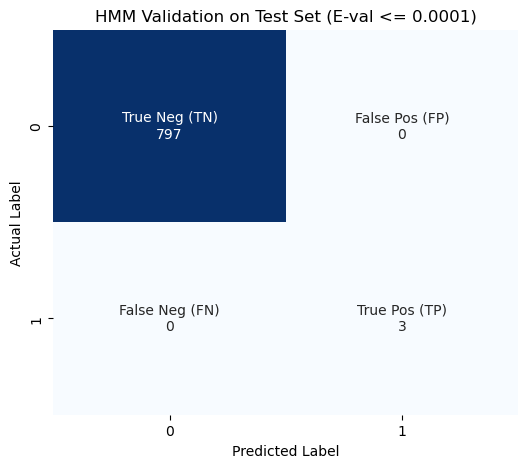


Positive Test IDs (3): ['4ISN_B_kunitz', '5ZJ3_B_kunitz', '3WNY_B_kunitz']...
Predicted Positives (3): ['5ZJ3_B_kunitz', '3WNY_B_kunitz', '4ISN_B_kunitz']...

False Positives (0):
Empty DataFrame
Columns: [hit_id, evalue, bitscore]
Index: []

False Negatives (0):
Empty DataFrame
Columns: [hit_id, evalue, bitscore]
Index: []


In [14]:

if not hmm_validation_domtblout or not os.path.exists(hmm_validation_domtblout):
     raise FileNotFoundError(f"HMM search domain output file not found: {hmm_validation_domtblout}")

print("--- Parsing HMM Search Results and Evaluating ---")

# Use SearchIO to parse the domtblout file
qresults = list(SearchIO.parse(hmm_validation_domtblout, "hmmsearch3-domtab"))


data = []
hit_ids_found = set() # Keep track of which sequences had at least one significant hit

for qresult in qresults: # Iterate through queries (our HMM)
    for hit in qresult.hits: # Iterate through sequence hits
        hit_id = hit.id # Get the ID of the sequence that was hit
        hit_ids_found.add(hit_id)
        is_positive_truth = hit_id in positive_test_ids # Check if it's one of our known positives
        best_hsp = min(hit.hsps, key=lambda hsp: hsp.evalue) # Get HSP with lowest E-value
        data.append({
            "hit_id": hit_id,
            "is_positive_truth": is_positive_truth,
            "evalue": best_hsp.evalue,
            "bitscore": best_hsp.bitscore,
        })

# Get all sequence IDs from the combined test FASTA
all_test_seq_ids = set()
with open(combined_test_fasta_path, "r") as handle:
    for record in SeqIO.parse(handle, "fasta"):
        all_test_seq_ids.add(record.id)


missed_ids = all_test_seq_ids - hit_ids_found
print(f"Found {len(hit_ids_found)} sequences with hits. {len(missed_ids)} sequences had no hits passing threshold.")

for missed_id in missed_ids:
    is_positive_truth = missed_id in positive_test_ids
    data.append({
        "hit_id": missed_id,
        "is_positive_truth": is_positive_truth,
        "evalue": float('inf'), # Assign infinite E-value for non-hits
        "bitscore": float('-inf'), # Assign very low bitscore
    })


df_hmm_results = pd.DataFrame(data)

# --- Calculate Confusion Matrix ---
# Define a threshold E-value for classification (can be same as search_e_value or stricter)
classification_threshold = 0.0001 # Example: stricter threshold for classification

df_hmm_results['predicted_positive'] = df_hmm_results['evalue'] <= classification_threshold

# Map True/False to 1/0 if needed by confusion_matrix, though boolean should work
y_true = df_hmm_results['is_positive_truth']
y_pred = df_hmm_results['predicted_positive']

cm = confusion_matrix(y_true, y_pred)

print(f"\nConfusion Matrix (Threshold E-value <= {classification_threshold}):")
print(cm)

# Calculate metrics
tn, fp, fn, tp = cm.ravel()
total = tp + tn + fp + fn
accuracy = (tp + tn) / total if total > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0 # Also called Sensitivity
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Specificity:{specificity:.4f}")
print(f"F1-score:  {f1_score:.4f}")

# Plotting confusion matrix
plt.figure(figsize=(6, 5))
group_names = ['True Neg (TN)', 'False Pos (FP)', 'False Neg (FN)', 'True Pos (TP)']
group_counts = ["{:,}".format(value) for value in cm.flatten()]
# group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)] # , group_percentages Removed percentage for clarity
labels = np.asarray(labels).reshape(2, 2)

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title(f'HMM Validation on Test Set (E-val <= {classification_threshold})')
plt.show()

print(f"\nPositive Test IDs ({len(positive_test_ids)}): {list(positive_test_ids)[:10]}...") # Show some positive IDs
print(f"Predicted Positives ({sum(y_pred)}): {df_hmm_results[y_pred]['hit_id'].tolist()[:10]}...")

# Display some False Positives and False Negatives
false_positives = df_hmm_results[(y_pred == True) & (y_true == False)]
false_negatives = df_hmm_results[(y_pred == False) & (y_true == True)]

print(f"\nFalse Positives ({len(false_positives)}):")
print(false_positives[['hit_id', 'evalue', 'bitscore']].head())

print(f"\nFalse Negatives ({len(false_negatives)}):")
# Note: FN 'evalue' will be > threshold or inf if not hit
print(false_negatives[['hit_id', 'evalue', 'bitscore']].head())



## Application: SwissProt Annotation and Comparison



### Searching SwissProt with the HMM



As a practical application, the validated Kunitz HMM is used to scan the entire UniProtKB/Swiss-Prot database (`uniprot_sprot.fasta`). `hmmsearch` is run again, this time targeting SwissProt, and domain hits below the E-value threshold are recorded in a domain table output file.


In [15]:
# Define paths for SwissProt annotation
swissprot_fasta_file = f"{SWISS_DIR}/swiss_all.fasta" # Assuming you have swiss_all.fasta or similar
hmm_file_for_swiss = hmm_file_path # Use the HMM built earlier
swiss_search_output_base = f"{SWISS_DIR}/hmmsearch_swissprot_kunitz"
swiss_search_e_value = 0.001 # E-value threshold for searching SwissProt

# Check if SwissProt FASTA file exists
if not os.path.exists(swissprot_fasta_file):
    raise FileNotFoundError(f"SwissProt FASTA file not found: {swissprot_fasta_file}. Please download it (e.g., uniprot_sprot.fasta).")


print(f"\n--- Searching SwissProt ({swissprot_fasta_file}) with HMM ---")
swiss_domtblout_path = run_hmmsearch(
    hmm_file_for_swiss,
    swissprot_fasta_file,
    swiss_search_output_base,
    e_value=swiss_search_e_value,
    use_max=False, # Get domain hits
    domtblout=True
)



--- Searching SwissProt (data/swiss_data/swiss_all.fasta) with HMM ---
Running hmmsearch: wsl hmmsearch --domtblout data/swiss_data/hmmsearch_swissprot_kunitz.domtbl --incE 0.001 data/hmms/kunitz_pf00014.hmm data/swiss_data/swiss_all.fasta > data/swiss_data/hmmsearch_swissprot_kunitz.txt


HMMER search completed. Domain results: data/swiss_data/hmmsearch_swissprot_kunitz.domtbl, Text output: data/swiss_data/hmmsearch_swissprot_kunitz.txt


### Parsing SwissProt Hits


In [16]:
if not swiss_domtblout_path or not os.path.exists(swiss_domtblout_path):
     raise FileNotFoundError(f"HMM search domain output file for SwissProt not found: {swiss_domtblout_path}")

print("--- Parsing SwissProt HMM Search Results ---")
swiss_results = []

swiss_qresults = SearchIO.parse(swiss_domtblout_path, "hmmsearch3-domtab")
for qresult in swiss_qresults:
    for hit in qresult.hits:
            # Parse UniProt ID (handle different header formats like sp|P00974|...)
            uniprot_id_parts = hit.id.split('|')
            if len(uniprot_id_parts) >= 2:
                uniprot_id = uniprot_id_parts[1] # Usually the accession is the second part
            else:
                uniprot_id = hit.id # Fallback to the full ID

            for hsp in hit.hsps:
                swiss_results.append({
                    "uniprot_id": uniprot_id,
                    "full_hit_id": hit.id, # Keep the full ID for reference
                    "evalue": hsp.evalue,
                    "bitscore": hsp.bitscore,
                    "domain_start": hsp.hit_start, # Start/end of the domain hit in the sequence
                    "domain_end": hsp.hit_end,
                    "query_start": hsp.query_start, # Start/end match in the HMM
                    "query_end": hsp.query_end,
                })

df_swissprot_hmm = pd.DataFrame(swiss_results)
# Sort by E-value to see the best hits first
df_swissprot_hmm = df_swissprot_hmm.sort_values(by="evalue").reset_index(drop=True)

print(f"Found {len(df_swissprot_hmm)} potential Kunitz domain hits in SwissProt (based on E-value <= {swiss_search_e_value}).")
print(df_swissprot_hmm.head())

# Save the results to a CSV
swiss_results_csv_path = f"{SWISS_DIR}/swissprot_kunitz_hmm_hits.csv"
df_swissprot_hmm.to_csv(swiss_results_csv_path, index=False)
print(f"SwissProt HMM search results saved to: {swiss_results_csv_path}")

--- Parsing SwissProt HMM Search Results ---
Found 493 potential Kunitz domain hits in SwissProt (based on E-value <= 0.001).
  uniprot_id            full_hit_id        evalue  bitscore  domain_start  \
0     P00974   sp|P00974|BPT1_BOVIN  2.100000e-25      93.5            38   
1     Q90WA0   sp|Q90WA0|VKT2_PSETT  1.900000e-24      90.4            29   
2     P00975   sp|P00975|IBPS_BOVIN  1.900000e-24      90.4             5   
3     Q7LZS8  sp|Q7LZS8|VKTRE_DENAN  2.400000e-24      90.1             5   
4     P0DMJ6  sp|P0DMJ6|VKT12_DENAN  2.400000e-24      90.1             5   

   domain_end  query_start  query_end  
0          90            0         52  
1          82            0         53  
2          57            0         52  
3          58            0         53  
4          58            0         53  
SwissProt HMM search results saved to: data/swiss_data/swissprot_kunitz_hmm_hits.csv


### Comparison with Curated SwissProt Annotations



To further evaluate the HMM's real-world accuracy, its predictions on SwissProt are compared against the manually curated Pfam annotations present within SwissProt itself.
1.  **Parsing Annotations:** The official SwissProt data file (`uniprot_sprot.dat`) is parsed to extract the primary accession number and all associated Pfam domain annotations for each entry. This information serves as a reference or "ground truth". *Parsing this file is slow, so results are cached to `swissprot_annotations.csv`.*
2.  **Comparison:** The set of UniProt IDs predicted by the HMM (hits below the E-value threshold) is compared against the set of UniProt IDs officially annotated with PF00014 in SwissProt.
3.  **Evaluation:** TP, FP, FN, and TN counts are calculated based on this comparison, providing insight into the HMM's performance on a large, diverse, and curated dataset. A confusion matrix visualizing this comparison is plotted, and example discrepancies (FPs, FNs relative to SwissProt annotations) are examined.

In [17]:
def parse_swissprot_dat(dat_file):
    """Parse SwissProt .dat file and extract primary accessions and Pfam domain IDs."""
    data, entry = [], {}
    count = 0

    print(f"Parsing SwissProt .dat file: {dat_file} ... (This may take time)")

    with open(dat_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('//'):
                if 'AC' in entry:
                    entry['AC'] = entry['AC'].split(';')[0].strip()
                    data.append(entry)
                    count += 1
                    if count % 10000 == 0:
                        print(f"  Processed {count} entries...")
                entry = {}
                continue

            if line.startswith('AC'):
                entry['AC'] = entry.get('AC', '') + line[5:]
            elif line.startswith('DR'):
                entry['DR'] = entry.get('DR', '') + '\n' + line[5:] if 'DR' in entry else line[5:]

    print(f"Finished parsing. Total entries processed: {count}")

    if not data:
        print("Warning: No data parsed from .dat file.")
        return pd.DataFrame()

    df = pd.DataFrame(data)
    print("Extracting Pfam domains from DR fields...")
    df['Pfam'] = df['DR'].apply(lambda x: re.findall(r"Pfam;\s*(PF\d+);", x) if isinstance(x, str) else [])
    del df['DR']
    gc.collect()
    return df[['AC', 'Pfam']]


# --- Load or Create Annotations ---
annotations_csv = f"{SWISS_DIR}/swissprot_annotations.csv"
dat_file = f"{SWISS_DIR}/uniprot_sprot.dat" # Make sure this exists

if os.path.exists(annotations_csv):
    print(f"--- Loading existing annotations from {annotations_csv} ---")
    df_annotations = pd.read_csv(annotations_csv)
else:
    print(f"--- No annotation CSV file found. Parsing {dat_file} ---")
    df_annotations = parse_swissprot_dat(dat_file)
    print("Parsed the data, now saving to CSV...")
    df_annotations.to_csv(annotations_csv, index=False)
    print(f"SwissProt Pfam annotations saved to: {annotations_csv}")

df_annotations.head()

--- Loading existing annotations from data/swiss_data/swissprot_annotations.csv ---


,AC,SQ,Pfam
0,Q6GZX4,NaN,['PF04947']
1,Q6GZX3,NaN,['PF03003']
2,Q197F8,NaN,[]
3,Q197F7,NaN,[]
4,Q6GZX2,NaN,[]



Comparison with SwissProt PF00014 Annotations:
  True Positives (HMM predicted, Pfam annotated): 390
  False Positives (HMM predicted, NOT Pfam ann.): 3
  False Negatives (NOT HMM predicted, Pfam ann.): 7
  True Negatives (NOT HMM predicted, NOT Pfam ann.): 572570

Evaluation Metrics:
Accuracy:  1.0000
Precision: 0.9924
Recall:    0.9824
Specificity:1.0000
F1-score:  0.9873


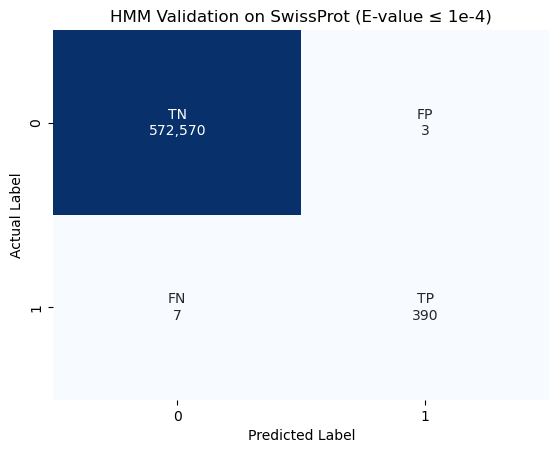

In [18]:
# --- Evaluation ---
if  df_annotations.empty:
    raise ValueError("No annotation data available. Cannot proceed with evaluation.")

annotated = set(df_annotations[df_annotations['Pfam'].apply(lambda x: 'PF00014' in x)]['AC'])
predicted = set(df_swissprot_hmm[df_swissprot_hmm['evalue'] <= swiss_search_e_value]['uniprot_id'])

tp = len(predicted & annotated)
fp = len(predicted - annotated)
fn = len(annotated - predicted)
tn = len(df_annotations) - len(annotated) - fp

print("\nComparison with SwissProt PF00014 Annotations:")
print(f"  True Positives (HMM predicted, Pfam annotated): {tp}")
print(f"  False Positives (HMM predicted, NOT Pfam ann.): {fp}")
print(f"  False Negatives (NOT HMM predicted, Pfam ann.): {fn}")
print(f"  True Negatives (NOT HMM predicted, NOT Pfam ann.): {tn}")

# --- Metrics ---
total = tp + tn + fp + fn
accuracy = (tp + tn) / total if total > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0 # Also called Sensitivity
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\nEvaluation Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Specificity:{specificity:.4f}")
print(f"F1-score:  {f1_score:.4f}")

cm = np.array([[tn, fp], [fn, tp]])
labels = ['TN', 'FP', 'FN', 'TP']
counts = [f"{v:,}" for v in cm.flatten()]
sns.heatmap(cm, annot=np.array([f"{l}\n{c}" for l, c in zip(labels, counts)]).reshape(2, 2),
            fmt='', cmap='Blues', cbar=False)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('HMM Validation on SwissProt (E-value ≤ 1e-4)')
plt.show()

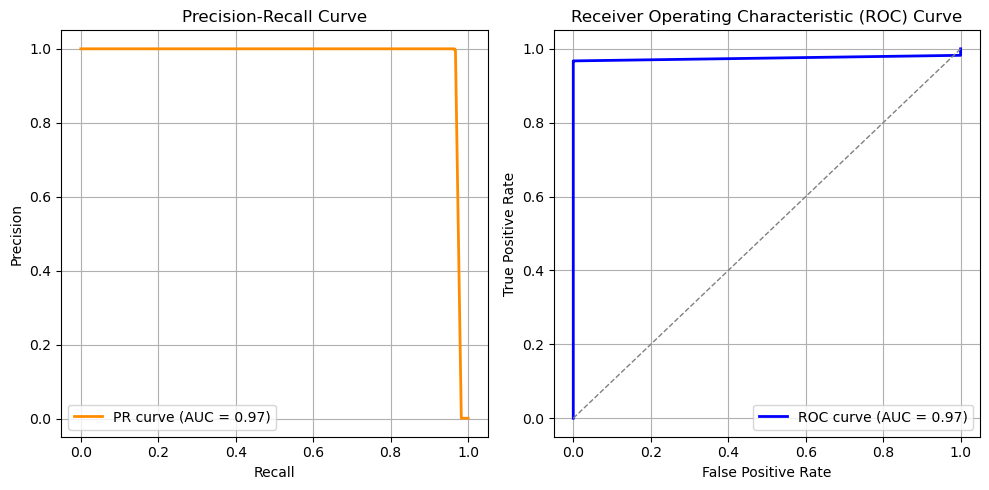

In [19]:
# All unique ACs in SwissProt
all_acs = df_annotations['AC'].tolist()

# Ground truth: 1 if annotated with PF00014, else 0
y_true = [1 if ac in annotated else 0 for ac in all_acs]

# Get prediction scores: use -log10(evalue), or 0 if not predicted (i.e., not found in HMM hits)
evalue_dict = dict(zip(df_swissprot_hmm['uniprot_id'], df_swissprot_hmm['evalue']))
max_evalue = max(evalue_dict.values()) if evalue_dict else 1e-4

y_scores = [-np.log10(evalue_dict[ac]) if ac in evalue_dict else 0 for ac in all_acs]

# --- Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_true, y_scores)
pr_auc = auc(recall, precision)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()


In [20]:
print("\nExample False Positives:")
fp_ids = list(predicted - annotated)
print(fp_ids[:5])
df_swissprot_hmm[df_swissprot_hmm['uniprot_id'].isin(predicted - annotated)].head()



Example False Positives:
['P15989', 'O76840', 'P05067']


,uniprot_id,full_hit_id,evalue,bitscore,domain_start,domain_end,query_start,query_end
77,P05067,sp|P05067|A4_HUMAN,1.600000e-21,81.1,289,341,0,52
246,P15989,sp|P15989|CO6A3_CHICK,2.500000e-18,70.8,3070,3122,0,52
270,O76840,sp|O76840|PPN1_CAEEL,1.400000e-17,68.4,1851,1904,0,53
305,O76840,sp|O76840|PPN1_CAEEL,1.900000e-16,64.8,1503,1554,1,52
349,O76840,sp|O76840|PPN1_CAEEL,4.500000e-15,60.4,1912,1964,0,52


In [21]:
print("\nExample False Negatives:")
fn_ids = list(annotated - predicted)
print(fn_ids[:5])
df_swissprot_hmm[df_swissprot_hmm['uniprot_id'].isin(fn_ids)].sort_values('evalue', ascending=False).head()


Example False Negatives:
['O62247', 'NISPG VVTTIGT', 'Q8WPG5', 'Q9UC33', 'D3GGZ8']


,uniprot_id,full_hit_id,evalue,bitscore,domain_start,domain_end,query_start,query_end
488,Q8WPG5,sp|Q8WPG5|KUNI_ORNKA,420.000,6.0,55,66,41,52
477,Q8WPG5,sp|Q8WPG5|KUNI_ORNKA,0.048,18.7,87,129,9,52
